<a href="https://colab.research.google.com/github/IgorAkO/Simulative_ML/blob/main/2%20DatAnPyt%20/S_ML_2_4_FinProject_Scooter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Тесовое задание орг. Самокат
### Описание данных
**Таблица products:**  
product_id - id товара  
level1 - категория  
level2 - подкатегория  
name - наименование товара      

**Таблица orders:**  
order_id - номер чека  
accepted_at - дата и время чека  
product_id - id товара  
quantity - кол-во товара в чеке  
regular_price - регулярная цена  
price - текущая цена  
cost_price - закупочная цена

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Считываем таблицы orders и products
products = pd. read_excel('products.xlsx')
orders = pd.read_excel('orders.xlsx')

# Сводим таблицы
df = orders.merge(products, on='product_id', how='left')

# df:
# отсутствуют nan
# 'accepted_at' в формате datetime
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3323 non-null   int64         
 1   accepted_at    3323 non-null   datetime64[ns]
 2   product_id     3323 non-null   int64         
 3   quantity       3323 non-null   int64         
 4   regular_price  3323 non-null   int64         
 5   price          3323 non-null   int64         
 6   cost_price     3323 non-null   int64         
 7   level1         3018 non-null   object        
 8   level2         3018 non-null   object        
 9   name           3010 non-null   object        
dtypes: datetime64[ns](1), int64(6), object(3)
memory usage: 259.7+ KB


### ### 1. Самая ходовая товарная группа

По какой категории товаров продано больше всего позиций?

1. Подкрепите свой ответ таблицей, в которой рассчитано количество проданных штук товара в каждой товарной категории.
2. Дополнительно постройте на основании этой таблицы `barchart`.
3. Проверьте, чтобы все подписи на вашем графике выглядели читаемо и понятно. Этот график должен быть сходу понятен стороннему наблюдателю.

In [ ]:
n_prod = df.groupby('level1')['quantity'].agg({'sum'}).reset_index()
n_prod = n_prod.sort_values('sum', ascending=True)
n_prod.head(2)

,level1,sum
22,Специальное питание,2
5,Детство (Гигиена и Уход),6


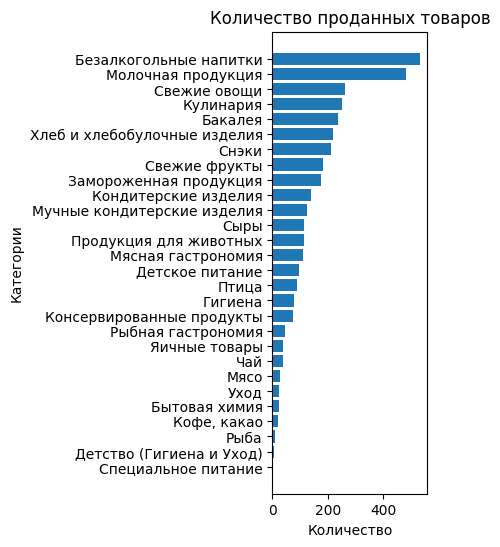

In [ ]:
plt.figure(figsize=(2, 6))
plt.barh(n_prod['level1'], n_prod['sum'])

plt.title('Количество проданных товаров')
plt.xlabel('Количество')
plt.ylabel('Категории')

plt.show()

### 2. Распределение продаж по подкатегориям
Оцените распределение количества проданных позиций в каждой товарной категории (`level1`) по подкатегориям (`level2`). Проиллюстрируйте свой результат расчетной таблицей.

In [ ]:
ord_level1_2 = df.groupby(['level1', 'level2']).agg(quantity=('quantity', 'sum')).reset_index()
ord_level1_2 = ord_level1_2.sort_values('quantity', ascending=False)
ord_level1_2.head(2)

,level1,level2,quantity
13,Безалкогольные напитки,Напитки,252
54,Кулинария,Готовые блюда,248


### 3. Найти средний чек в заданную дату
Какой средний чек был 13.01.2022?

In [ ]:
df['date'] = df['accepted_at'].dt.strftime('%Y-%m-%d')
mean_ord_price = df[df['date'] == '2022-01-13'].groupby('order_id').apply(lambda x: (x['price'] * x['quantity']).sum(), include_groups=False).mean()
print(mean_ord_price.round(2))

915.64


### 4. Доля промо в заданной категории
Когда товар продается по промо-акции, его базовая цена не совпадает с фактической ценой.

Вам необходимо:
1. Посчитать, какую долю от общих продаж категории `Сыры` занимают промо (в штуках)
2. Построить пайчарт, который это проиллюстрирует. На графике должны быть видны группы, соответствующие доли и понятные подписи к ним.

In [ ]:
df['promo'] = df['price'] < df['regular_price']
promo_cheeses = df[df['level1']=='Сыры']['promo'].value_counts(normalize=True).round(3)*100
promo_cheeses = promo_cheeses.reset_index()
print(promo_cheeses.iloc[1,1])

32.1


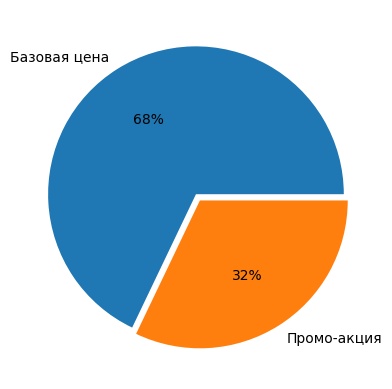

In [ ]:
labels = ['Базовая цена', 'Промо-акция']
plt.pie(promo_cheeses['proportion'], autopct='%.0f%%',labels=labels, explode=[0, 0.05]);

### 5. Посчитать маржу по категориям
Нужно посчитать маржу:
1. В рублях
2. В `%`

In [ ]:
# Определяем функцию прибыли по категориям в рублях (prof_rub)
# и процентах от суммы закупки в категории (prof_per)
def profit(x):
    d = {}
    d['prof_rub'] = sum((x['price'] - x['cost_price'])*x['quantity'])
    d['prof_per'] = 100 * d['prof_rub'] / sum(x['price']*x['quantity'])
    return pd.Series(d, index=['prof_rub', 'prof_per'])

In [ ]:
# Прибыль по категориям в рублях
profit = (
    df.groupby('level1')
    .apply(profit, include_groups=False)
    .reset_index()
    .sort_values('prof_rub', ascending=False)
)

# Прибыль по категория в процентах от общего дохода
profit['prof_per2'] = (100 * profit['prof_rub'] / profit['prof_rub'].sum()).round(2)

profit.head(2)

,level1,prof_rub,prof_per,prof_per2
1,Безалкогольные напитки,20373.0,44.186349,12.10
10,Кулинария,18452.0,45.181195,10.96


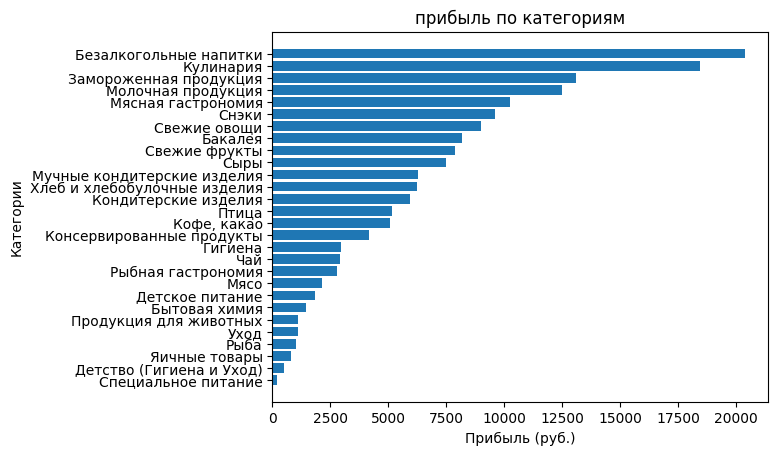

In [ ]:
profit = profit.sort_values('prof_rub', ascending=True)

plt.barh(profit['level1'], profit['prof_rub'])

plt.title('прибыль по категориям')
plt.xlabel('Прибыль (руб.)')
plt.ylabel('Категории')

plt.show()

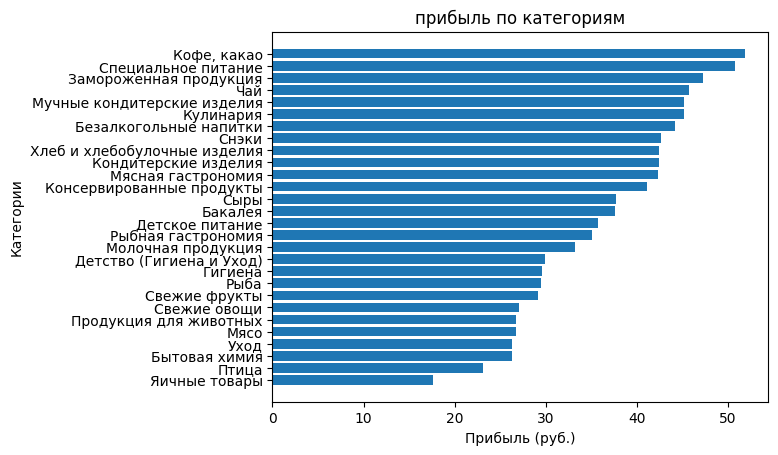

In [ ]:
profit = profit.sort_values('prof_per', ascending=True)

plt.barh(profit['level1'], profit['prof_per'])

plt.title('прибыль по категориям')
plt.xlabel('Прибыль (руб.)')
plt.ylabel('Категории')

plt.show()

### 6. ABC анализ
1. Сделайте ABC-анализ продаж по количеству
2. Сделайте ABC-анализ по сумме продаж
3. Сделайте новый столбец, в котором будет итоговая группа на основании двух анализов. Например: `A C`.

In [ ]:
# Определяем функцию ABC расчета по колонкам cols
# после группировки по параметру param в таблице ABC
def perfirm_ABC(ABC, param):
  cols = list(ABC.columns)
  cols.remove(param)
  gr_ABC = ABC.groupby(param).agg({col: 'sum' for col in cols}).reset_index()

  for col in cols:
    gr_ABC = gr_ABC.sort_values(col, ascending=False)
    gr_ABC[f'rel_{col}'] = gr_ABC[col] / gr_ABC[col].sum()

    gr_ABC[f'cumsum_{col}'] = gr_ABC[f'rel_{col}'].cumsum()
    gr_ABC[f'ABC_{col}'] = np.where(
        gr_ABC[f'cumsum_{col}'] < 0.8, 'A',
        np.where(gr_ABC[f'cumsum_{col}'] < 0.95, 'B', 'C')
        )
  return gr_ABC[cols + [f'ABC_{col}' for col in cols]]

In [ ]:
df6 = df[['level2', 'quantity']].copy()
df6['inc'] = df['price'] * df['quantity']

param = 'level2'
gr_ABC = perfirm_ABC(df6, param)
gr_ABC['ABC_q+inc'] = gr_ABC.filter(like='ABC').apply(' '.join, axis=1)
#gr_ABC['ABC_q+inc'] = gr_ABC[['ABC_quantity', 'ABC_inc']].apply(' '.join, axis=1)

gr_ABC[25:50]

,quantity,inc,ABC_quantity,ABC_inc,ABC_q+inc
99,40,4419,A,A,A_A
65,15,4343,B,A,B_A
97,29,4265,B,A,B_A
54,25,4237,B,A,B_A
12,20,4161,B,A,B_A
96,26,3890,B,A,B_A
78,12,3765,B,A,B_A
30,34,3542,B,B,B_B
66,8,3460,C,B,C_B
76,24,3411,B,B,B_B


In [ ]:
#orders.head(2)
#products.head(2)
df.head(5)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
